# Classifier for PathMNIST

This notebook trains a multiclass classifier on PathMNIST in PyTorch. We begin with a simple MLP, before moving on to a CNN. 

## Multilayer Perceptron

In [54]:
import numpy as np
import torch
import torchvision
import torchvision.transforms.v2 as T
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import torchmetrics

load the data file w/ numpy, then turn all the of features into a seperate tensor for train/test/val respectively

In [55]:
data = np.load('data/pathmnist.npz') # load file using numpy

In [56]:
tensors = {name: torch.from_numpy(data[name]) for name in data.files}

In [57]:
for name, t in tensors.items():
    print(f'{name:15} {tuple(t.shape)} {t.dtype}')

train_images    (89996, 28, 28, 3) torch.uint8
val_images      (10004, 28, 28, 3) torch.uint8
test_images     (7180, 28, 28, 3) torch.uint8
train_labels    (89996, 1) torch.uint8
val_labels      (10004, 1) torch.uint8
test_labels     (7180, 1) torch.uint8


So now we have a dict of train/test/val images (inputs) and labels (target) tensors. We can now properly turn them into our data.

We also need to change the pixel values in each tensor to a tensor float32 and scale them by dividing by 255 to compress everything in a 0-1 range


In [58]:
for name in tensors.keys():
    tensors[name] = tensors[name]

In [59]:
X_train = tensors['train_images'].to(torch.float32) / 255
X_val = tensors['val_images'].to(torch.float32) / 255
X_test = tensors['test_images'].to(torch.float32) / 255

y_train = torch.flatten(tensors['train_labels'])
y_val = torch.flatten(tensors['val_labels'])
y_test = torch.flatten(tensors['test_labels'])

Now we have our data setup. 

Each image is a 28x28 grid of pixels, with each pixel value represented as a 3 entry vector reprenting it's RGB colour channel.

We also flattened the targets, so it's 1 vector with N entires for our loss function to work

For our future CNN, we should rework this so it's 3 28x28 grids representing each colour instead, but not needed rn since an MLP flattens this image

In [60]:
X_train = torch.permute(X_train, (0, 3, 1, 2))
X_val = torch.permute(X_val, (0, 3, 1, 2))
X_test = torch.permute(X_test, (0, 3, 1, 2))

In [61]:
X_train.size()

torch.Size([89996, 3, 28, 28])

Now we need to create our DataSet objects and our data loaders

In [62]:

train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128)
test_loader = DataLoader(test_dataset, batch_size=128)

Now that we have our data loaders, we can build the classification MLP

We will create a custom module, but it's really just a sequential module, custom is just cleaner and easier to fine tune hyperparams

n_inputs is the # of features (3x28x28), n_classes is the # of output classes (9)

note that we don't apply softmax (converts logits to probs) on the output layer, so the model outputs logits (raw class scores)

this is because we use cross entropy loss as our loss function, which computes loss straight from the logits

In [63]:
class MLPClassifier(nn.Module):
    def __init__(self, n_inputs, n_hidden1, n_hidden2, n_classes):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Flatten(), # flatten the 3x28x28 image for matmul w/ weights to work
            nn.Linear(n_inputs, n_hidden1),
            nn.ReLU(),
            nn.Linear(n_hidden1, n_hidden2),
            nn.ReLU(),
            nn.Linear(n_hidden2, n_classes)
        )

    def forward(self, X):
        return self.mlp(X)

We have our model now, so now we can focus on training it. 

We can pick our loss function, (Cross Entropy), our learning rate, and our optimizer (SGD, but we can use it with batch gd)
- optimizer adjusts the models parameters according to the learning rate and the loss 

In [64]:
device = 'mps'
torch.manual_seed(42)

model = MLPClassifier(n_inputs=3*28*28, n_hidden1=500, n_hidden2=200, n_classes=9)
model = model.to(device)

xentropy = nn.CrossEntropyLoss()

learning_rate = 1e-3

# change optimizer from SGD to Adam 
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

Now that we have our model, loss function, and optimizer we need to write our training loop

In [65]:
def train_one_epoch(model, optimizer, criterion, train_loader, epoch=1):
    model.train()
    total_loss = 0.
    for X_batch, y_batch, in train_loader: 
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)
        total_loss += loss.item()
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    print(f'Loss for epoch {epoch}: {total_loss / len(train_loader)}')

def train(train_one_epoch, model, optimizer, criterion, train_loader, n_epochs):
    for epoch in range(n_epochs):
        train_one_epoch(model, optimizer, criterion, train_loader, epoch + 1)



Now let's train our model on the gpu

In [66]:
n_epochs = 20
train(train_one_epoch, model, optimizer, xentropy, train_loader, n_epochs)

Loss for epoch 1: 1.7031039986759424
Loss for epoch 2: 1.4339012510397218
Loss for epoch 3: 1.3614385910332203
Loss for epoch 4: 1.3254010264169087
Loss for epoch 5: 1.297241936861114
Loss for epoch 6: 1.2714771723205394
Loss for epoch 7: 1.2582035069777207
Loss for epoch 8: 1.2333287760954013
Loss for epoch 9: 1.2150243518196724
Loss for epoch 10: 1.2021127328784629
Loss for epoch 11: 1.1828338830647143
Loss for epoch 12: 1.161768732423132
Loss for epoch 13: 1.1435978427867999
Loss for epoch 14: 1.1224766522222622
Loss for epoch 15: 1.1107684179971165
Loss for epoch 16: 1.0996010289950804
Loss for epoch 17: 1.075512359172783
Loss for epoch 18: 1.0586199663918128
Loss for epoch 19: 1.0490040386264974
Loss for epoch 20: 1.0301594356582924


We tried SGD, but Adam seems to be the better optimizer for us

Now let's write a function to evaluate the model

In [67]:
def evaluate(model, data_loader, metric_fn, aggregate_fn=torch.mean):
    model.eval()
    metrics = []
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            metric = metric_fn(y_pred, y_batch)
            metrics.append(metric)

    return aggregate_fn(torch.stack(metrics))

Choose the Accuracy streaming metric, move to gpu. mean works fine as our aggregate for now 
- computes by comparing the idx of the highest value logit, and comparing it to the corresponding label.

In [68]:
accuracy = torchmetrics.Accuracy(task='multiclass', num_classes=9).to(device)

In [69]:
evaluate(model, val_loader, accuracy)

tensor(0.5628, device='mps:0')

Accuracy of the model is not terrible for a simple MLP. Let's try fine tuning it before moving on to something more complex. 

In [ ]:
import optuna

def objective(trial):
    learning_rate = trial.suggest_float('learning_rate', 1e-5, 1e-1, log=True)
    n_hidden1 = trial.suggest_int('n_hidden1', 20, 300)
    n_hidden2 = trial.suggest_int('n_hidden2', 20, 300)
    model = MLPClassifier(n_inputs=3*28*28, n_hidden1=n_hidden1, n_hidden2=n_hidden2, n_classes=9).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    train(train_one_epoch, model, optimizer, xentropy, train_loader, n_epochs)
    validation_accuracy = evaluate(model, val_loader, accuracy)
    return validation_accuracy

/Users/zainbabar/code/shiftmon/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
torch.manual_seed(42)
sampler = optuna.samplers.TPESampler(seed=42)
study = optuna.create_study(direction='maximize', sampler=sampler)
study.optimize(objective, n_trials=10)

In [ ]:
study.best_params

{'learning_rate': 0.0024810409748678114, 'n_hidden1': 63, 'n_hidden2': 63}

In [ ]:
study.best_value

0.6190071105957031

This looks like this is the best it's gonna get with a basic MLP, now let's try something better

## Convolutional Neural Network

Let's write a CNN now. We can reuse our data loaders, training and evaluation functions from before, we just need to makea new model. 

We are going to use a simple, LeNet-5 style architecture, since the data is not very complicated, only 28x28 images. 
The architecture will have 2 sets of 2 convolutional layers followed by relus and then a max pooling layer, and then a fully connected layer, followed by the final output layer. 
The output layer will output raw logits, without softmax for our cross entropy loss function.

In [70]:
from functools import  partial
DefaultConv2d = partial(nn.Conv2d, kernel_size=3, stride=1, padding='same') # prefilled args to avoid repeated code

class CNNClassifier(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.layers = nn.Sequential( # stack layers in a sequential module 
            DefaultConv2d(in_channels=3, out_channels=32), nn.ReLU(),
            DefaultConv2d(in_channels=32, out_channels=32), nn.ReLU(),
            nn.MaxPool2d(2),
            DefaultConv2d(in_channels=32, out_channels=64), nn.ReLU(),
            DefaultConv2d(in_channels=64, out_channels=64), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(), # flatten for our fully connected layer, since it takes 1d vector/matrix 
            nn.LazyLinear(128), nn.ReLU(), # use lazy linear so we don't have to worry abt input size, it auto adjusts # of weights
            nn.LazyLinear(n_classes), # outputs our 9 logits
        )

    def forward(self, inputs):
        return self.layers(inputs)



We use a stride of 1 and a kernel size of 3x3, so we keep the spatial dimensions the same until we hit the pooling layers. Padding is set to 'same', which ensures that our output feature maps are the same size as our inputs. When we hit the pooling layers we double the channels, since by this point we can encode richer features in our feature map while dropping the spatial dimensions of the image (choose 1 pixel from every two with the highest signal). We also use ReLU as our activation function after each convolutional layer.

After we are done with the convolutional layers we flatten the feature maps into a vector for the fully connected layer to allow for it to matrix multiply properly. We use LazyLinear instead of Linear since it auto adjust the number of weights needed without us having to keep track. Then our final layer outputs 9 logits, representing our class scores. 

note that our linear layer takes in 7x7 pixels * 64 channels per pixel = 3136 inputs
- pooling 1 took us from 28x28 -> 14x14, pooling 2 does 14x14 -> 7x7 by picking pixels as mentioned above

Now that we've created our CNN, time to train and evaluate it.

In [71]:
torch.manual_seed(42)
# reuse the same loss, lr, and optimizer from before 

model = CNNClassifier(9)
model = model.to(device)

xentropy = nn.CrossEntropyLoss()

learning_rate = 1e-3

optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [72]:
n_epochs = 20
train(train_one_epoch, model, optimizer, xentropy, train_loader, n_epochs)

Loss for epoch 1: 1.105935064567761
Loss for epoch 2: 0.638774951200255
Loss for epoch 3: 0.5186234428547323
Loss for epoch 4: 0.42755449152636255
Loss for epoch 5: 0.3695017108905383
Loss for epoch 6: 0.31012293201109226
Loss for epoch 7: 0.2847273649002256
Loss for epoch 8: 0.2513601876456629
Loss for epoch 9: 0.2276207705832679
Loss for epoch 10: 0.21229308579032394
Loss for epoch 11: 0.18973611487308517
Loss for epoch 12: 0.17106753019933504
Loss for epoch 13: 0.15865048673003912
Loss for epoch 14: 0.1463795883464627
Loss for epoch 15: 0.1362288928834129
Loss for epoch 16: 0.12442163055873773
Loss for epoch 17: 0.1133932312077377
Loss for epoch 18: 0.10885138812326742
Loss for epoch 19: 0.09456396116663447
Loss for epoch 20: 0.09397922749419442


In [73]:
evaluate(model, val_loader, accuracy)

tensor(0.9445, device='mps:0')

In [74]:
evaluate(model, test_loader, accuracy)

tensor(0.8804, device='mps:0')

Using our evaluate function that measures mean accuracy over all batches, we get 94.4% accuracy on test, and 88% on trian. Pretty solid. Maybe fine tuning it could improve, but nothing significant (later?). Compared to our MLP, this is much better.

> **note**: the test data in PathMNIST is already from a different source, which explains the drop in test accuracy

Now let's test it's *robustness* on altered data, to see if it would hold up in the real world.
- this is a harsh test of the classifier, since the test said already showed how it would act between different sensors
- corrupted data is more of a test of a *broken* sensor, rather than a different one 

## Robustness Eval

Let's write some functions that corrupt the images by adding noise, reducing contrast, and blurring them, things that could arise in the real world based on scanner issues, (sensor issues, staining/exposure differences, and focus problems respectively) and different scanner models.

These corruption functions will help us get an idea of how deviations affect our model. 

All the functions take in the set of images to corrupt, and a severity level, which we map to a multiplier.

In [ ]:
def sev_dist(severity):
    vals = [0.02, 0.03, 0.04, 0.05, 0.06] # mapping of values for adjustable severity (1-5)
    return vals[severity - 1]

First we will write a function to add noise. We will add noise manually via `torch.randn_like`. 
`torch.randn_like` creates a tensor with random values (std dist, mean 0, var 1) with the same dimensions as the input image(s), and then we can add that to the image with a severity multiplier to control how noisy we want the image to be.  

In [ ]:
def add_noise(images, severity): # clamp the output so the pixel intensities don't go out of our range
    return (images + (sev_dist(severity) * torch.randn_like(images))).clamp(0, 1) 

For our contrast reducing function, we want to lower the differences between the bright/dark (high/low value) pixels. So we want to shift all of the pixels intensities towards the mean of the current image, making it a more uniform intensity over the image.

Images is a [n, 3, 28, 28] tensor, where n is the size of the batch of images, and each image has 3 channels/28x28 pixels. We want the mean per channel to effectively blur out all the colours. 

In [77]:
def reduce_contrast(images, severity): 
    mean = images.mean(dim=(2,3),  keepdim=True) # take the mean of of dims 2 and 3 (height/width pixels) per channel
    # the shape of mean is (n, 3, 1, 1)
    # now we have the means per channel per image for all the images 
    # subtracting this from the images tensor would subtract the mean from dims 2 and 3 
    images = mean + (1 - 0.15 * severity) * (images - mean)
    return images


for blur, we will use the build in torchvision gaussian blur function, with some predefined values for sigma

In [78]:
def blur(images, severity):
    sigmas = [0.4, 0.5, 0.6, 0.8, 1.0]
    blur = T.GaussianBlur(kernel_size=(2 * severity + 1, 2 * severity + 1), sigma=sigmas[severity - 1])
    return blur(images)

let's look at all the corruption functions over all severities applied to some images

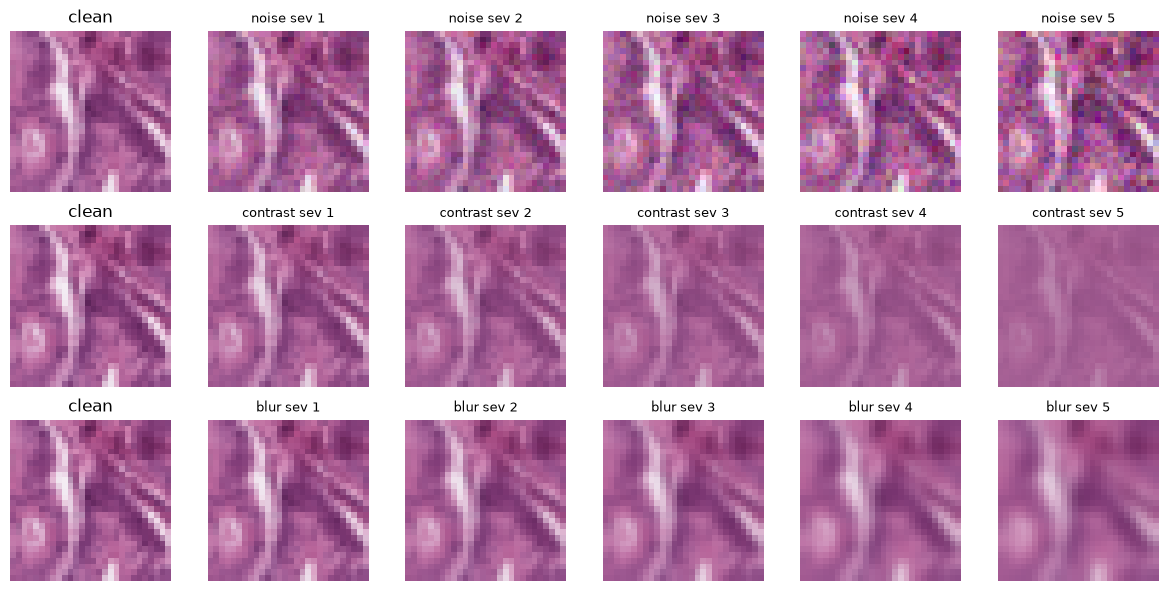

In [79]:
import matplotlib.pyplot as plt

def show_corruptions(image, corruption_fns, severities=range(1, 6)):
    batch = image.unsqueeze(0)  # add a batch dim of 1, since its cur a single image & corruption fn expect batch
    fig, axes = plt.subplots(
        len(corruption_fns), len(severities) + 1,
        figsize=(2 * (len(severities) + 1), 2 * len(corruption_fns)),
    )
    for row, (name, fn) in enumerate(corruption_fns.items()):
        axes[row, 0].imshow(image.permute(1, 2, 0).cpu().numpy())
        axes[row, 0].set_title('clean')
        axes[row, 0].axis('off')
        for col, severity in enumerate(severities, start=1):
            corrupted = fn(batch, severity)[0].clamp(0, 1)
            axes[row, col].imshow(corrupted.permute(1, 2, 0).cpu().numpy())
            axes[row, col].set_title(f'{name} sev {severity}', fontsize=9)
            axes[row, col].axis('off')
    plt.tight_layout()
    plt.show()

sample_image = X_test[0]
show_corruptions(sample_image, {
    'noise': add_noise,
    'contrast': reduce_contrast,
    'blur': blur,
})

Corruption functions work properly, now let's test the models accuracy on the corrupted data. 

Only the test set gets corrupted, the model was trained and tuned on clean data.

Same thing as our evaluate function, just with one extra line: 
- corrupt each batch before it goes to the gpu, so we're corrupting the raw [0, 1] pixels.

In [80]:
def evaluate_corrupted(model, data_loader, metric_fn, corruption, severity, aggregate_fn=torch.mean):
    model.eval()
    metrics = []
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch = corruption(X_batch, severity) # corrupt the batch first
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            metric = metric_fn(y_pred, y_batch)
            metrics.append(metric)

    return aggregate_fn(torch.stack(metrics))

Clean accuracy is our baseline, nothing is corrupted here, so the gap between val and test isnt from our corruptions

In [81]:
clean_val = evaluate(model, val_loader, accuracy).item()
clean_test = evaluate(model, test_loader, accuracy).item()
print(clean_val, clean_test)

0.9445015788078308 0.8804368376731873


go through all the corruptions and severities and get the models accuracy for each. 

also reset the seed every time so the random noise is the same on every run since contrast and blur aren't random

In [82]:
corruptions = {'noise': add_noise, 'contrast': reduce_contrast, 'blur': blur}

results = {}
for name, corruption in corruptions.items():
    results[name] = []
    for severity in range(1, 6):
        torch.manual_seed(42) # same noise every run
        acc = evaluate_corrupted(model, test_loader, accuracy, corruption, severity)
        results[name].append(acc.item())

results

{'noise': [0.8520193099975586,
  0.7909813523292542,
  0.6756212711334229,
  0.5299250483512878,
  0.3573647737503052],
 'contrast': [0.8490954041481018,
  0.7540204524993896,
  0.6016539335250854,
  0.4413377046585083,
  0.2861842215061188],
 'blur': [0.8453947305679321,
  0.6856725811958313,
  0.5851151347160339,
  0.44275403022766113,
  0.3513340950012207]}

plot accuracy vs severity w/ one line per corruption 
clean accuracy as is our baseline

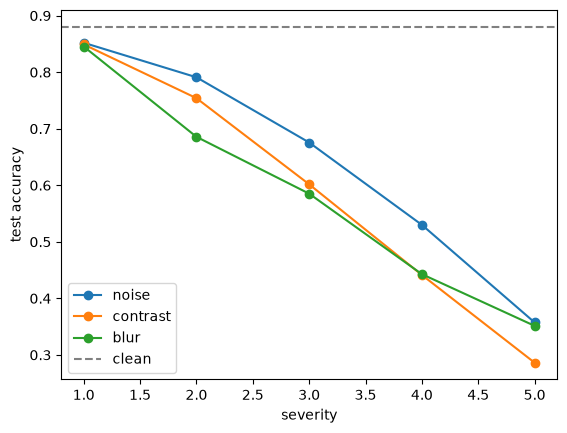

In [83]:
for name, accs in results.items():
    plt.plot(range(1, 6), accs, marker='o', label=name)

plt.axhline(clean_test, linestyle='--', color='gray', label='clean')
plt.xlabel('severity')
plt.ylabel('test accuracy')
plt.legend()
plt.show()

Accuracy drops of pretty linearly over all the functions as the severity gets worse, though our corruption functions were quite harsh. So this could cause a real risk in real world conditions. 